# 06 — IC Decay Analysis

**Purpose**: Measure how long each factor group's predictive signal persists across horizons.
Key questions:
1. At which horizon does each factor group achieve peak IC?
2. How fast does IC decay from 1y → 3y → 5y? (half-life estimation)
3. Is IC decay regime-conditional (bull vs bear markets)?
4. Which factor groups are "short-horizon" vs "long-horizon" signals?

**Data**: `historical_dataset_clean.parquet` + `reports/factor_research_*.csv`  
**Factor groups**: Value · Quality · Momentum · Growth · Fraud Risk  
**Horizons**: 1y · 3y · 5y (forward return available)

---

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

HORIZONS = ['1y', '3y', '5y']
HORIZON_YEARS = {'1y': 1, '3y': 3, '5y': 5}
BEAR_YEARS = {2008, 2009, 2020, 2022}  # GFC, COVID, rate-hike bear

# Factor group feature membership — verified against parquet columns
FACTOR_GROUPS = {
    'Value':      ['pb_ratio', 'pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield',
                   'earnings_yield', 'book_to_market'],
    'Quality':    ['roe', 'roa', 'roic', 'piotroski_f_score', 'altman_z_score',
                   'gross_margin', 'operating_margin', 'accruals_to_assets',
                   'sloan_wc_accruals', 'sloan_lt_accruals'],
    'Momentum':   ['momentum_12m_rank', 'momentum_6m_rank', 'momentum_3m_rank',
                   'momentum_composite_rank'],
    'Growth':     ['revenue_growth_yoy', 'eps_growth_yoy', 'revenue_cagr_3y'],
    'FraudRisk':  ['beneish_m_score', 'montier_c_score', 'alpha_fraud_risk',
                   'ml_1y', 'ml_3y', 'ml_5y'],
}

print("Imports loaded. ROOT =", ROOT)


Imports loaded. ROOT = /Users/mhoque/Documents/stock-fraud-screener


In [2]:
# Load factor research CSVs (pre-computed IC/ICIR per feature per horizon)
factor_dfs = {}
for h in HORIZONS:
    path = ROOT / 'reports' / f'factor_research_{h}.csv'
    if path.exists():
        factor_dfs[h] = pd.read_csv(path)
        print(f"  {h}: {len(factor_dfs[h])} features  columns: {list(factor_dfs[h].columns[:8])}")
    else:
        print(f"  {h}: NOT FOUND — run scripts/factor_research.py first")

# Load parquet for direct annual IC computation — IC-ready markets only
ALL_FEATURES = [f for grp in FACTOR_GROUPS.values() for f in grp]
LOAD_COLS = (
    ['ticker', 'market', 'fiscal_year',
     'forward_return_1y', 'forward_return_3y', 'forward_return_5y']
    + ALL_FEATURES
)
df_raw = pd.read_parquet(
    ROOT / 'data' / 'historical_dataset_clean.parquet',
    columns=[c for c in LOAD_COLS]
)
df_raw = df_raw[df_raw['market'].isin(['US', 'KR', 'CA', 'JP'])]
print(f"\nParquet loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")
print(f"IC-ready markets: {df_raw['market'].value_counts().to_dict()}")
print(f"Fiscal years: {int(df_raw.fiscal_year.min())} – {int(df_raw.fiscal_year.max())}")


  1y: 241 features  columns: ['feature', 'ic', 'mean_ic', 'std_ic', 'icir', 'ic_tstat', 'pct_positive_ic', 'n_years']
  3y: 240 features  columns: ['feature', 'ic', 'mean_ic', 'std_ic', 'icir', 'ic_tstat', 'pct_positive_ic', 'n_years']
  5y: 236 features  columns: ['feature', 'ic', 'mean_ic', 'std_ic', 'icir', 'ic_tstat', 'pct_positive_ic', 'n_years']

Parquet loaded: 56,069 rows x 36 cols
IC-ready markets: {'US': 44059, 'CA': 8955, 'KR': 2538, 'JP': 517}
Fiscal years: 2008 – 2027


In [3]:
# Compute annual cross-sectional Spearman IC per feature per horizon per year
# IC(feature, horizon, year) = Spearman(feature_score, forward_return_horizon)

FORWARD_COLS = {'1y': 'forward_return_1y', '3y': 'forward_return_3y', '5y': 'forward_return_5y'}
available = [f for f in ALL_FEATURES if f in df_raw.columns]
missing = set(ALL_FEATURES) - set(available)
if missing:
    print(f"  [WARN] {len(missing)} features missing from parquet: {sorted(missing)}")

years = sorted(df_raw['fiscal_year'].unique())
MIN_TICKERS = 30

ic_records = []
for yr in years:
    yr_df = df_raw[df_raw['fiscal_year'] == yr]
    for h, fwd_col in FORWARD_COLS.items():
        y = yr_df[fwd_col].dropna()
        if len(y) < MIN_TICKERS:
            continue
        for feat in available:
            x = yr_df.loc[y.index, feat]
            valid = x.notna() & y.notna()
            if valid.sum() < MIN_TICKERS:
                continue
            rho, _ = stats.spearmanr(x[valid], y[valid])
            ic_records.append({'feature': feat, 'horizon': h, 'fiscal_year': yr, 'ic': rho, 'n': valid.sum()})

ic_df = pd.DataFrame(ic_records)
print(f"IC matrix: {len(ic_df):,} records  ({ic_df['feature'].nunique()} features x {len(HORIZONS)} horizons x {len(years)} years)")
ic_df.head(3)


IC matrix: 1,326 records  (30 features x 3 horizons x 20 years)


,feature,horizon,fiscal_year,ic,n
0,pb_ratio,1y,2009,0.017783,102
1,pe_ratio,1y,2009,-0.209237,101
2,ps_ratio,1y,2009,-0.051944,119


In [4]:
# Assign factor groups and aggregate mean IC per (group, horizon, year)
feat_to_group = {f: g for g, flist in FACTOR_GROUPS.items() for f in flist}
ic_df['group'] = ic_df['feature'].map(feat_to_group)

ic_grp = (
    ic_df.groupby(['group', 'horizon', 'fiscal_year'])['ic']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'mean_ic', 'std': 'std_ic', 'count': 'n_features'})
)
ic_grp['horizon_year'] = ic_grp['horizon'].map(HORIZON_YEARS)
print(f"Group-level IC table: {ic_grp.shape}")
ic_grp.head(6)


Group-level IC table: (221, 7)


,group,horizon,fiscal_year,mean_ic,std_ic,n_features,horizon_year
0,FraudRisk,1y,2009,0.028007,0.028749,5,1
1,FraudRisk,1y,2010,0.115651,0.118172,6,1
2,FraudRisk,1y,2011,0.164293,0.138878,6,1
3,FraudRisk,1y,2012,0.161019,0.118419,6,1
4,FraudRisk,1y,2013,0.236940,0.187799,6,1
5,FraudRisk,1y,2014,0.244746,0.202712,6,1


In [5]:
# Summary table: mean_IC, std_IC, n_years, IR per group x horizon
summary_rows = []
for (grp, h), sub in ic_grp.groupby(['group', 'horizon']):
    mean_ic = sub['mean_ic'].mean()
    std_ic  = sub['mean_ic'].std()
    n_years = len(sub)
    ir = mean_ic / std_ic if std_ic > 0 else np.nan
    summary_rows.append({'group': grp, 'horizon': h, 'mean_IC': round(mean_ic, 4),
                         'std_IC': round(std_ic, 4), 'n_years': n_years,
                         'IC_IR': round(ir, 3)})

summary = pd.DataFrame(summary_rows)
summary = summary.sort_values(['group', 'horizon'])
print(summary.to_string(index=False))


    group horizon  mean_IC  std_IC  n_years  IC_IR
FraudRisk      1y   0.1634  0.1013       17  1.614
FraudRisk      3y   0.2613  0.0588       15  4.443
FraudRisk      5y   0.3015  0.0595       13  5.067
   Growth      1y   0.0087  0.0552       16  0.158
   Growth      3y   0.0156  0.0497       14  0.313
   Growth      5y  -0.0013  0.0684       12 -0.019
 Momentum      1y   0.0276  0.1117       17  0.247
 Momentum      3y   0.0407  0.0905       15  0.449
 Momentum      5y   0.0171  0.1304       13  0.131
  Quality      1y   0.0587  0.0521       17  1.126
  Quality      3y   0.0701  0.0577       15  1.215
  Quality      5y   0.0722  0.0504       13  1.433
    Value      1y   0.0475  0.0785       17  0.605
    Value      3y   0.0744  0.0653       15  1.138
    Value      5y   0.0782  0.0662       12  1.180


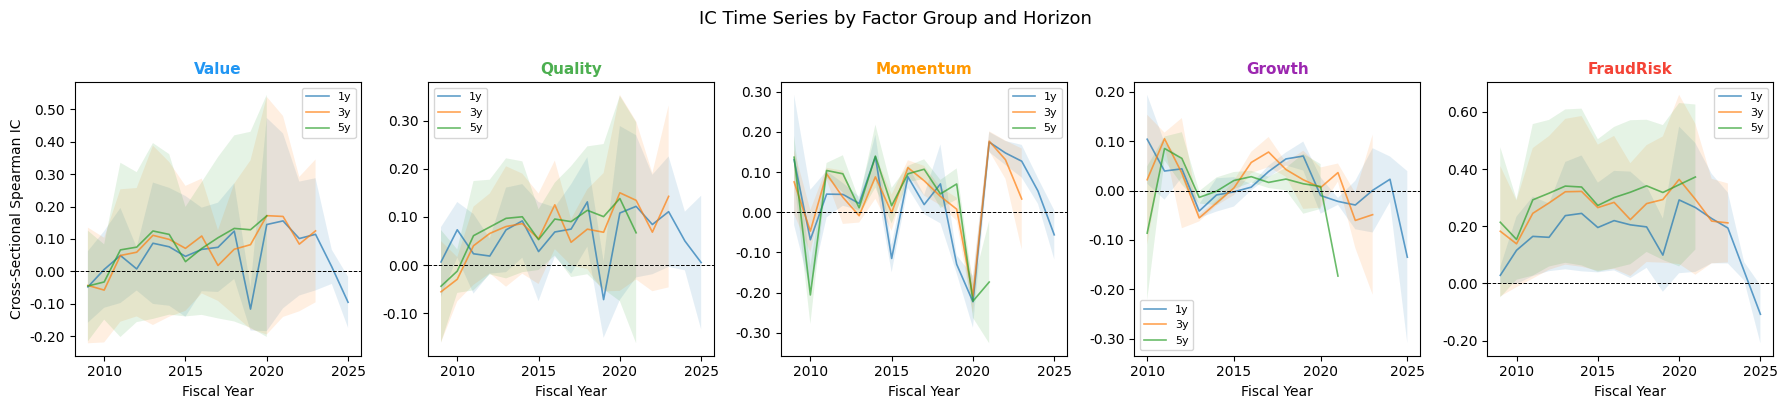

Saved: reports/ic_decay_by_group.png


In [6]:
# IC decay curves: mean IC by horizon year, per factor group
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)
COLORS = {'Value': '#2196F3', 'Quality': '#4CAF50', 'Momentum': '#FF9800',
          'Growth': '#9C27B0', 'FraudRisk': '#F44336'}

for ax, grp in zip(axes, ['Value', 'Quality', 'Momentum', 'Growth', 'FraudRisk']):
    sub = ic_grp[ic_grp['group'] == grp]
    for h in HORIZONS:
        hdata = sub[sub['horizon'] == h].sort_values('fiscal_year')
        if hdata.empty:
            continue
        ax.plot(hdata['fiscal_year'], hdata['mean_ic'],
                label=h, linewidth=1.2, alpha=0.7)
        ax.fill_between(hdata['fiscal_year'],
                        hdata['mean_ic'] - hdata['std_ic'],
                        hdata['mean_ic'] + hdata['std_ic'],
                        alpha=0.12)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(grp, fontsize=11, color=COLORS.get(grp, 'black'), fontweight='bold')
    ax.set_xlabel('Fiscal Year')
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

axes[0].set_ylabel('Cross-Sectional Spearman IC')
fig.suptitle('IC Time Series by Factor Group and Horizon', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'ic_decay_by_group.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/ic_decay_by_group.png")


In [7]:
# Half-life estimation: fit IC_peak * exp(-lambda * (t - 1)) across horizons 1y -> 3y -> 5y
def exp_decay(t, ic0, lam):
    return ic0 * np.exp(-lam * (t - 1))

halflife_rows = []
for grp in FACTOR_GROUPS:
    sub = summary[summary['group'] == grp].set_index('horizon')
    ics = [sub.loc[h, 'mean_IC'] for h in HORIZONS if h in sub.index]
    ts  = [HORIZON_YEARS[h] for h in HORIZONS if h in sub.index]
    if len(ics) < 2:
        continue
    try:
        popt, _ = curve_fit(exp_decay, ts, ics, p0=[max(abs(x) for x in ics) or 0.01, 0.3],
                            maxfev=2000, bounds=([0, 0], [1, 10]))
        ic0, lam = popt
        halflife = np.log(2) / lam if lam > 1e-6 else np.inf
    except Exception:
        ic0, lam, halflife = np.nan, np.nan, np.nan
    halflife_rows.append({'group': grp, 'IC_0': round(ic0, 4), 'lambda': round(lam, 4),
                          'half_life_years': round(halflife, 2)})

hl_df = pd.DataFrame(halflife_rows)
print("IC half-life estimates (IC(t) = IC_0 * exp(-lambda * (t-1))):")
print(hl_df.to_string(index=False))


IC half-life estimates (IC(t) = IC_0 * exp(-lambda * (t-1))):
    group   IC_0  lambda  half_life_years
    Value 0.0667  0.0000              inf
  Quality 0.0670  0.0000              inf
 Momentum 0.0329  0.0758             9.14
   Growth 0.0114  0.2106             3.29
FraudRisk 0.2421  0.0000              inf


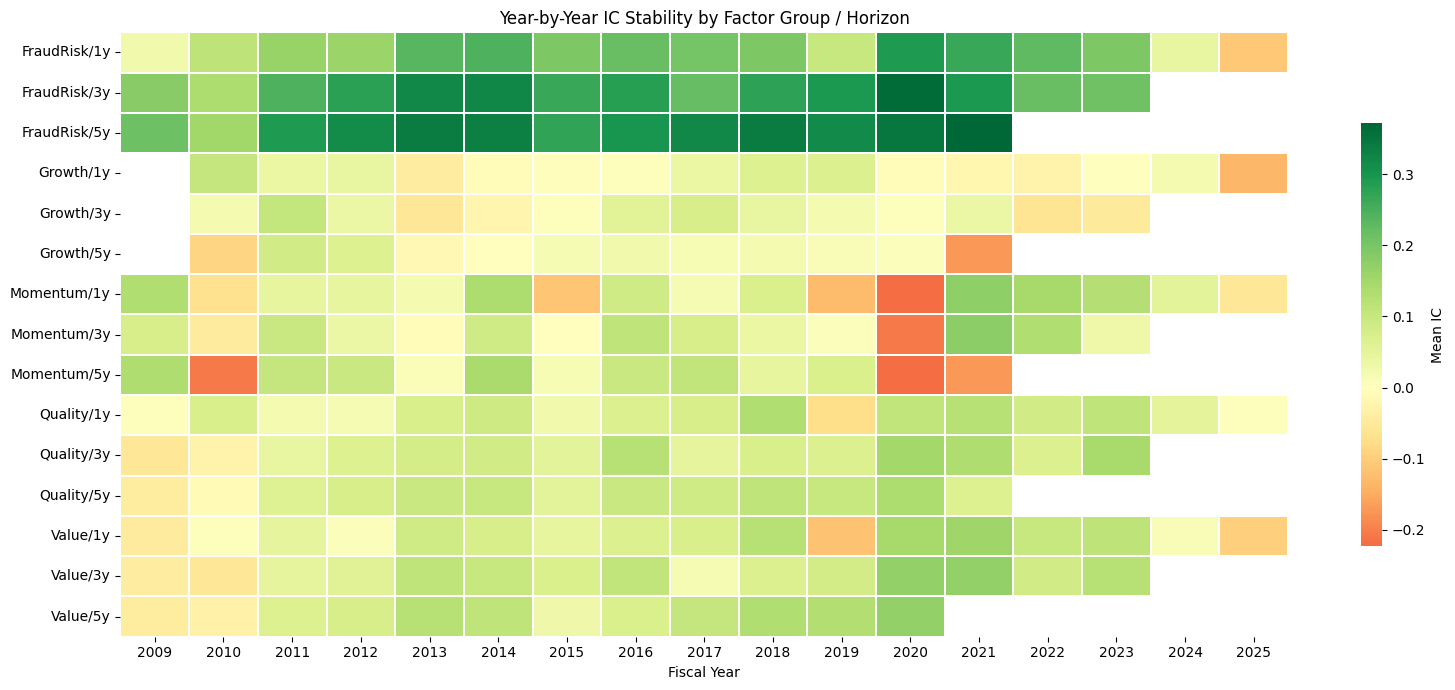

Saved: reports/ic_stability_heatmap.png


In [8]:
# Year-by-year IC stability heatmap per group x horizon
pivot_rows = []
for (grp, h), sub in ic_grp.groupby(['group', 'horizon']):
    for _, row in sub.iterrows():
        pivot_rows.append({'label': f'{grp}/{h}', 'fiscal_year': row['fiscal_year'], 'mean_ic': row['mean_ic']})

pivot = (pd.DataFrame(pivot_rows)
         .pivot(index='label', columns='fiscal_year', values='mean_ic')
         .sort_index())

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot, center=0, cmap='RdYlGn', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Mean IC', 'shrink': 0.7})
ax.set_title('Year-by-Year IC Stability by Factor Group / Horizon', fontsize=12)
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'ic_stability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/ic_stability_heatmap.png")


Regime-conditional mean IC (positive = Expansion better):
    group horizon  Bear/Crisis  Expansion  regime_lift
FraudRisk      1y     0.182209   0.159382    -0.022827
FraudRisk      3y     0.254614   0.262973     0.008359
FraudRisk      5y     0.279463   0.305548     0.026085
   Growth      1y    -0.019800   0.012766     0.032566
   Growth      3y    -0.027347   0.022719     0.050067
   Growth      5y     0.008070  -0.002132    -0.010202
 Momentum      1y     0.018466   0.029587     0.011121
 Momentum      3y    -0.000636   0.050991     0.051628
 Momentum      5y    -0.042066   0.027916     0.069982
  Quality      1y     0.066257   0.057061    -0.009196
  Quality      3y     0.054279   0.074090     0.019811
  Quality      5y     0.047104   0.076769     0.029665
    Value      1y     0.065910   0.043528    -0.022382
    Value      3y     0.070791   0.075257     0.004466
    Value      5y     0.063017   0.081190     0.018172


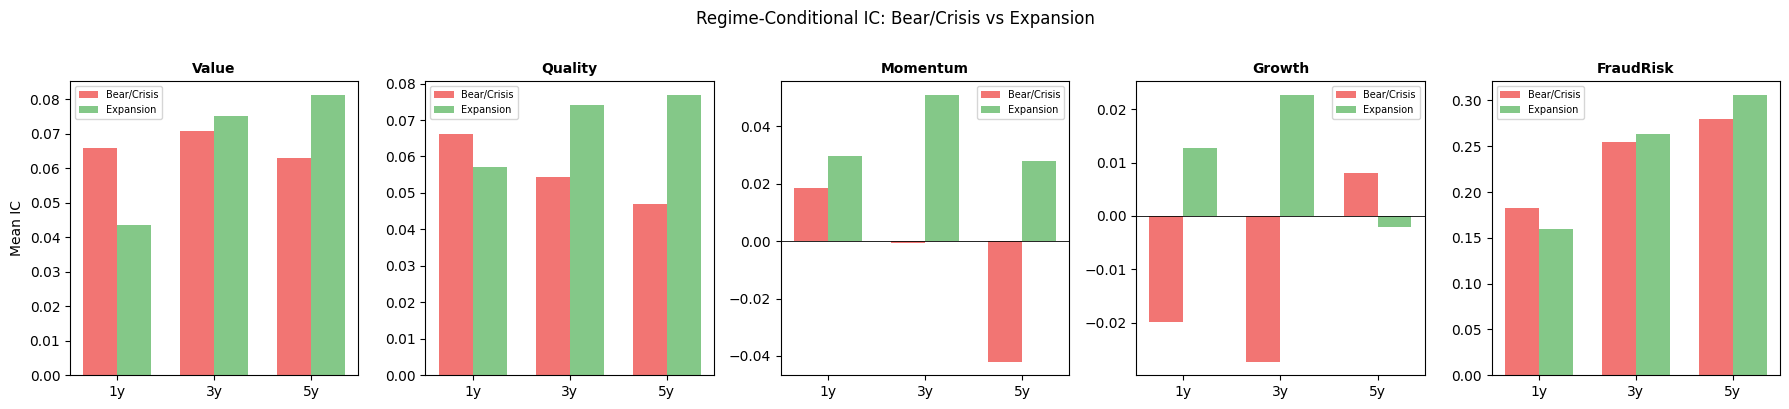

Saved: reports/ic_regime_decay.png


In [9]:
# Regime-conditional IC: Bear/Crisis vs Expansion years
ic_grp['regime'] = ic_grp['fiscal_year'].apply(
    lambda y: 'Bear/Crisis' if y in BEAR_YEARS else 'Expansion'
)

regime_summary = (
    ic_grp.groupby(['group', 'horizon', 'regime'])['mean_ic']
    .mean().reset_index()
    .pivot_table(index=['group', 'horizon'], columns='regime', values='mean_ic')
    .reset_index()
)
regime_summary['regime_lift'] = regime_summary.get('Expansion', 0) - regime_summary.get('Bear/Crisis', 0)
print("Regime-conditional mean IC (positive = Expansion better):")
print(regime_summary.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, grp in zip(axes, ['Value', 'Quality', 'Momentum', 'Growth', 'FraudRisk']):
    sub = regime_summary[regime_summary['group'] == grp]
    x = np.arange(len(HORIZONS))
    w = 0.35
    bear_vals   = [sub[sub['horizon']==h]['Bear/Crisis'].values[0] if not sub[sub['horizon']==h].empty and 'Bear/Crisis' in sub.columns else 0 for h in HORIZONS]
    expand_vals = [sub[sub['horizon']==h]['Expansion'].values[0]   if not sub[sub['horizon']==h].empty and 'Expansion'    in sub.columns else 0 for h in HORIZONS]
    ax.bar(x - w/2, bear_vals,   w, label='Bear/Crisis', color='#EF5350', alpha=0.8)
    ax.bar(x + w/2, expand_vals, w, label='Expansion',   color='#66BB6A', alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(x); ax.set_xticklabels(HORIZONS)
    ax.set_title(grp, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Mean IC')
fig.suptitle('Regime-Conditional IC: Bear/Crisis vs Expansion', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'ic_regime_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/ic_regime_decay.png")


IC lag-1 autocorrelation (year-over-year IC persistence):
    group horizon  lag1_autocorr  p_value
FraudRisk      1y          0.523   0.0377
FraudRisk      3y          0.517   0.0585
FraudRisk      5y          0.584   0.0464
   Growth      1y          0.275   0.3215
   Growth      3y          0.381   0.1984
   Growth      5y         -0.115   0.7359
 Momentum      1y         -0.058   0.8310
 Momentum      3y         -0.234   0.4215
 Momentum      5y          0.030   0.9272
  Quality      1y         -0.246   0.3575
  Quality      3y          0.536   0.0484
  Quality      5y          0.658   0.0200
    Value      1y         -0.011   0.9671
    Value      3y          0.585   0.0279
    Value      5y          0.708   0.0148


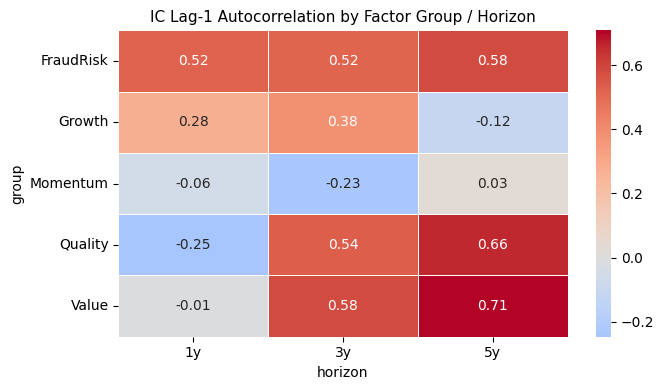

Saved: reports/ic_autocorrelation.png


In [10]:
# IC lag-1 autocorrelation: year-over-year persistence of factor signal
autocorr_rows = []
for (grp, h), sub in ic_grp.groupby(['group', 'horizon']):
    series = sub.sort_values('fiscal_year')['mean_ic'].values
    if len(series) >= 4:
        rho, p = stats.pearsonr(series[:-1], series[1:])
        autocorr_rows.append({'group': grp, 'horizon': h,
                               'lag1_autocorr': round(rho, 3), 'p_value': round(p, 4)})

ac_df = pd.DataFrame(autocorr_rows)
print("IC lag-1 autocorrelation (year-over-year IC persistence):")
print(ac_df.to_string(index=False))

pivot_ac = ac_df.pivot(index='group', columns='horizon', values='lag1_autocorr')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot_ac, annot=True, fmt='.2f', center=0, cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('IC Lag-1 Autocorrelation by Factor Group / Horizon', fontsize=11)
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'ic_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/ic_autocorrelation.png")


In [11]:
# Summary diagnostic table: classify each factor group signal type
diag_rows = []
for grp in FACTOR_GROUPS:
    hl_row = hl_df[hl_df['group'] == grp]
    hl = hl_row['half_life_years'].values[0] if len(hl_row) else np.nan
    ac_row = ac_df[ac_df['group'] == grp]
    ac_1y = ac_row[ac_row['horizon'] == '1y']['lag1_autocorr'].values
    ac_1y = ac_1y[0] if len(ac_1y) else np.nan
    ic_1y = summary[(summary['group'] == grp) & (summary['horizon'] == '1y')]['mean_IC'].values
    ic_1y = ic_1y[0] if len(ic_1y) else np.nan
    ic_5y = summary[(summary['group'] == grp) & (summary['horizon'] == '5y')]['mean_IC'].values
    ic_5y = ic_5y[0] if len(ic_5y) else np.nan

    if not np.isnan(hl):
        if hl < 2:
            sig_type = 'Short-horizon (fast decay)'
        elif hl > 5:
            sig_type = 'Long-horizon (slow decay)'
        else:
            sig_type = 'Medium-horizon'
    else:
        sig_type = 'Unknown'

    diag_rows.append({
        'Group': grp,
        'IC_1y': round(ic_1y, 4) if not np.isnan(ic_1y) else 'N/A',
        'IC_5y': round(ic_5y, 4) if not np.isnan(ic_5y) else 'N/A',
        'Half-life (yr)': round(hl, 1) if not np.isnan(hl) else 'N/A',
        'AC_1y': round(ac_1y, 3) if not np.isnan(ac_1y) else 'N/A',
        'Signal Type': sig_type,
    })

diag_df = pd.DataFrame(diag_rows)
print("=== Factor Group IC Diagnostic ===")
print(diag_df.to_string(index=False))
print("\n[Done] All outputs written to reports/")


=== Factor Group IC Diagnostic ===
    Group  IC_1y   IC_5y  Half-life (yr)  AC_1y               Signal Type
    Value 0.0475  0.0782             inf -0.011 Long-horizon (slow decay)
  Quality 0.0587  0.0722             inf -0.246 Long-horizon (slow decay)
 Momentum 0.0276  0.0171             9.1 -0.058 Long-horizon (slow decay)
   Growth 0.0087 -0.0013             3.3  0.275            Medium-horizon
FraudRisk 0.1634  0.3015             inf  0.523 Long-horizon (slow decay)

[Done] All outputs written to reports/
